# IMDb Movie Rating Prediction Using Machine Learning

## Introduction

In this project, we are going to predict the IMDb rating of a movie using
machine learning techniques.

The dataset contains information about movies such as genre, director,
year, runtime, number of votes, revenue and metascore.

The target variable in this project is the Rating column.

Since Rating is a numerical value, this is a regression problem.

The main steps of this project are:

1. Understanding the dataset
2. Exploratory Data Analysis
3. Data preprocessing
4. Handling missing values
5. Checking duplicates
6. Checking outliers
7. Feature engineering
8. Feature selection
9. Building different machine learning models
10. Evaluating and comparing the models
11. Selecting the best model
12. Predicting the rating for a new movie

## 1. Importing Libraries

First, we import the required Python libraries.

Pandas is used for handling the dataset.

NumPy is used for numerical operations.

Matplotlib and Seaborn are used for data visualization.

Scikit-learn is used for preprocessing, splitting the data,
building machine learning models and evaluating the models.

In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [260]:
from sklearn.model_selection import train_test_split

In [261]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [262]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [263]:
from sklearn.preprocessing import StandardScaler

In [264]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [265]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

In [266]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

In [267]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## 2. Loading the Dataset

Now we load the IMDb movie dataset using the read_csv() function.

The CSV file should be present in the same folder as this notebook.

After loading the dataset, we store it in a variable called df.

In [268]:
df = pd.read_csv("C:\\Users\\Tulasi\\Desktop\\IMDB Rating\\IMDB-Movie-Data.csv")

## 3. Displaying the Dataset

We display the first five rows of the dataset.

This helps us understand what type of information is available in the
dataset before starting the analysis.

In [269]:
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## 4. Checking the Size of the Dataset

The shape of the dataset tells us the number of rows and columns.

Rows represent movies and columns represent the features of each movie.

In [270]:
df.shape

(1000, 12)

The dataset contains 1000 movie records and 12 columns.

This means we have information about 1000 movies and 12 different
attributes related to those movies.

## 5. Checking Column Names

Now we display all the column names.

This helps us identify the available features and also helps us decide
which column should be used as the target variable.

In [271]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')

The important columns in the dataset include Genre, Director, Year,
Runtime, Rating, Votes, Revenue and Metascore.

The Rating column will be our target variable because our objective is
to predict the IMDb rating of a movie.

## 6. Checking the Data Types

We use info() to check the data type of every column and to see how
many non-null values are present.

This is important because machine learning algorithms require the data
to be in suitable formats.

In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


## 7. Statistical Summary

The describe() function gives statistical information about numerical
columns.

It shows values such as count, mean, standard deviation, minimum,
maximum and quartiles.

This helps us understand the numerical features before preprocessing.

In [273]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


## 8. Checking Missing Values

Missing values are values that are not available for some records.

We check the number of missing values in each column using isnull()
and sum().

This is important because missing values can cause problems while
training machine learning models.

In [274]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

The Revenue (Millions) column contains missing values and the Metascore
column also contains missing values.

We will handle these missing values during preprocessing instead of
simply deleting a large number of movie records.

In [275]:
df["Revenue (Millions)"] = df["Revenue (Millions)"].fillna(
    df["Revenue (Millions)"].median()
)

df["Metascore"] = df["Metascore"].fillna(
    df["Metascore"].median()
)

## 8. Checking Duplicate Records

Duplicate records contain the same information more than once.

We check for duplicate rows because duplicate data can affect the
performance of a machine learning model.

In [276]:
df.duplicated().sum()

np.int64(0)

In [277]:
df = df.drop_duplicates()

## 9. Checking Outliers and visualisation of the data

Outliers are unusually high or low values.

We check important numerical columns using boxplots.

We will not remove the outliers blindly because some high values,
such as very high movie revenue or votes, can be genuine values.

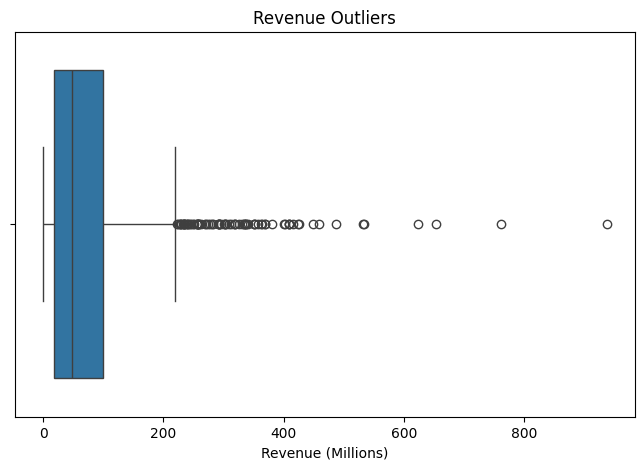

In [278]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Revenue (Millions)"])

plt.title("Revenue Outliers")
plt.show()

The boxplots show that some numerical features contain extreme values.

These values are retained because they may represent real movie data.

## Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the important
characteristics and patterns in the dataset.

The following visualizations are used to analyze the distribution of
IMDb ratings, the relationship between important features, possible
outliers, and correlations between numerical variables.

### Distribution of IMDb Ratings

A histogram is used to understand how the target variable, Rating,
is distributed across the dataset.

This visualization helps us understand the range and frequency of
IMDb movie ratings.

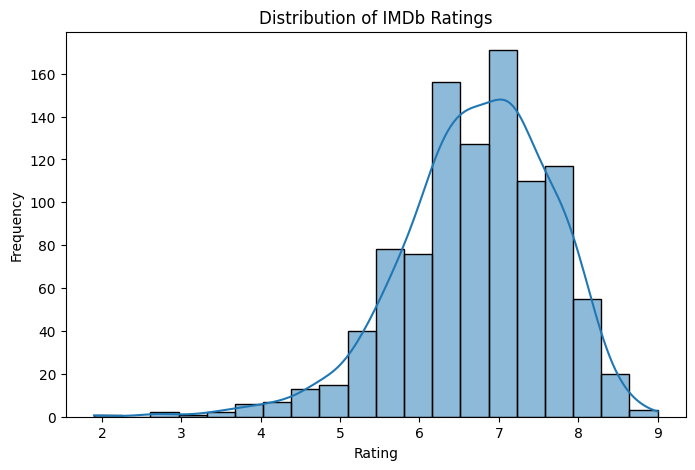

In [279]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Rating"], bins=20, kde=True)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

### Relationship Between IMDb Rating and Metascore

A scatter plot is used to examine the relationship between Metascore
and IMDb Rating.

This helps us understand whether movies with higher Metascores tend
to have higher IMDb ratings.

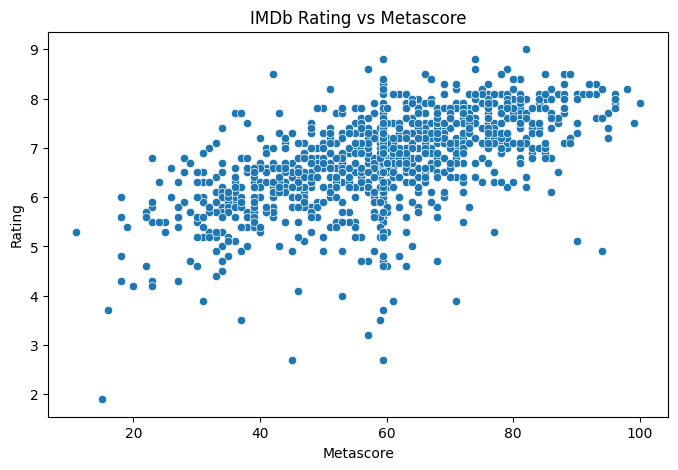

In [280]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Metascore",
    y="Rating"
)

plt.title("IMDb Rating vs Metascore")

plt.show()

### Correlation Between Numerical Features

A correlation heatmap is used to understand the relationship between
important numerical features and the target variable, Rating.

Correlation values closer to +1 indicate a positive relationship,
while values closer to -1 indicate a negative relationship.

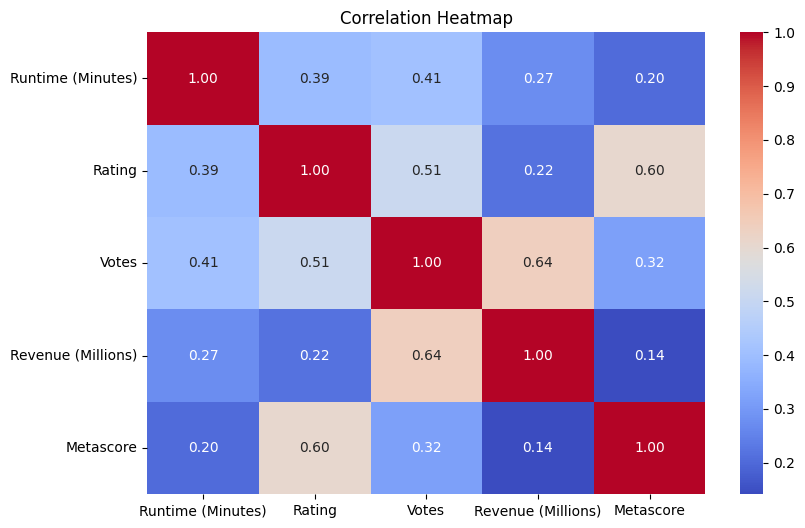

In [281]:
numeric_columns = [
    "Runtime (Minutes)",
    "Rating",
    "Votes",
    "Revenue (Millions)",
    "Metascore"
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 10. Feature Engineering

Feature engineering means creating a new useful feature from existing
features.

Here, we create a new feature called Movie_Age using the Year column.

Movie_Age represents how old a movie is compared with the latest year
available in the dataset.

In [282]:
latest_year = df["Year"].max()

df["Movie_Age"] = latest_year - df["Year"]

In [283]:
df[["Year", "Movie_Age"]].head()

,Year,Movie_Age
0,2014,2
1,2012,4
2,2016,0
3,2016,0
4,2016,0


## 11.Hypothesis Testing Using P-Values

Since this project is based on regression, p-values are calculated to
check whether important numerical features have a statistically
significant relationship with the IMDb Rating.

The significance level is set to 0.05. A p-value less than 0.05
indicates a statistically significant relationship.

In [284]:
from scipy.stats import pearsonr

features = [
    "Year",
    "Runtime (Minutes)",
    "Votes",
    "Revenue (Millions)",
    "Metascore"
]

print("P-Value Analysis:\n")

for feature in features:
    
    correlation, p_value = pearsonr(
        df[feature],
        df["Rating"]
    )
    
    if p_value < 0.05:
        result = "Significant"
    else:
        result = "Not Significant"
    
    print(
        feature,
        "| Correlation:",
        round(correlation, 4),
        "| P-value:",
        round(p_value, 6),
        "|",
        result
    )

P-Value Analysis:

Year | Correlation: -0.2112 | P-value: 0.0 | Significant
Runtime (Minutes) | Correlation: 0.3922 | P-value: 0.0 | Significant
Votes | Correlation: 0.5115 | P-value: 0.0 | Significant
Revenue (Millions) | Correlation: 0.2184 | P-value: 0.0 | Significant
Metascore | Correlation: 0.6045 | P-value: 0.0 | Significant


## 12. Feature Selection

We now select the features that will be used for prediction.

Rank is removed because it is mainly an ordering value.

Title, Description and Actors are text-based columns. We are not using
these columns in our basic structured-data model.

The Rating column is selected as the target because we want to predict
the IMDb rating.

In [285]:
X = df[
    [
        "Genre",
        "Director",
        "Year",
        "Runtime (Minutes)",
        "Votes",
        "Revenue (Millions)",
        "Metascore",
        "Movie_Age"
    ]
]

y = df["Rating"]

## 13. Data Preprocessing

Our dataset contains both numerical and categorical features.

Numerical features such as Year, Votes and Revenue can be used directly
after handling missing values and scaling.

Genre and Director are categorical features, so they need to be converted
into numerical values.

We use One-Hot Encoding for the categorical features.

In [286]:
numeric_features = [
    "Year",
    "Runtime (Minutes)",
    "Votes",
    "Revenue (Millions)",
    "Metascore",
    "Movie_Age"
]

In [287]:
categorical_features = [
    "Genre",
    "Director"
]

In [288]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [289]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [290]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 14. Splitting the Dataset

We divide the dataset into training and testing data.

80% of the data is used for training the model and 20% is used for
testing the model.

The testing data is not used during training, so it helps us check how
well the model performs on unseen data.

In [291]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


## 15. Linear Regression

Linear Regression is our first machine learning model.

It is a simple regression algorithm and is used as a baseline model.

We will compare its performance with other machine learning algorithms.

In [292]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [293]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Runtime (Minutes)',
                                                   'Votes',
                                                   'Revenue (Millions)',
                                                   'Metascore', 'Movie_Age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Genre', 'Director'])])),
                ('model', LinearRegression())])

In [294]:
linear_pred = linear_model.predict(X_test)

## 16. Evaluating Linear Regression

We use MAE, RMSE and R² score to evaluate the model.

MAE and RMSE should be lower for a better model.

R² should be higher for a better model.

In [295]:
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

MAE: 0.5424465985992452
RMSE: 0.7375132111294765
R2 Score: 0.43256189822431057


## 17. Random Forest Regression

Random Forest is an ensemble learning algorithm.

It uses multiple decision trees and combines their results.

It can handle non-linear relationships, so we use it to see whether
it performs better than Linear Regression for this dataset.

In [296]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [297]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Runtime (Minutes)',
                                                   'Votes',
                                                   'Revenue (Millions)',
                                                   'Metascore', 'Movie_Age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Genre', 'Director'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [298]:
rf_pred = random_forest_model.predict(X_test)

In [299]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 0.45724999999999966
RMSE: 0.6547307862778408
R2 Score: 0.5527973067004397


## 18. Gradient Boosting Regression

Gradient Boosting is another ensemble learning algorithm.

It builds models one after another and tries to reduce the errors made
by previous models.

We include it to compare another powerful regression technique.

In [300]:
gradient_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [301]:
gradient_model.fit(X_train, y_train)

gradient_pred = gradient_model.predict(X_test)

In [302]:
gradient_mae = mean_absolute_error(y_test, gradient_pred)

gradient_rmse = np.sqrt(
    mean_squared_error(y_test, gradient_pred)
)

gradient_r2 = r2_score(y_test, gradient_pred)

print("MAE:", gradient_mae)
print("RMSE:", gradient_rmse)
print("R2 Score:", gradient_r2)

MAE: 0.4673723804990775
RMSE: 0.6573375981231929
R2 Score: 0.5492291407706023


## 19. Comparing the Models

Now we compare the three models using MAE, RMSE and R² score.

A lower MAE and RMSE indicate smaller prediction errors.

A higher R² score indicates better performance.

In [303]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        linear_mae,
        rf_mae,
        gradient_mae
    ],
    
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gradient_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        rf_r2,
        gradient_r2
    ]
})

In [304]:
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.542447,0.737513,0.432562
1,Random Forest,0.457250,0.654731,0.552797
2,Gradient Boosting,0.467372,0.657338,0.549229


## 20. Selecting the Best Model

We select the model that gives the highest R² score.

We do not assume which model is best before seeing the results.

The actual evaluation results are used to make the final decision.

In [305]:
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


## 21. Actual vs Predicted Ratings

We compare the actual ratings with the ratings predicted by the best
model.

Predictions that are closer to the actual ratings indicate better
performance.

In [306]:
if best_model_name == "Linear Regression":
    best_model = linear_model
    best_pred = linear_pred

elif best_model_name == "Random Forest":
    best_model = random_forest_model
    best_pred = rf_pred

else:
    best_model = gradient_model
    best_pred = gradient_pred

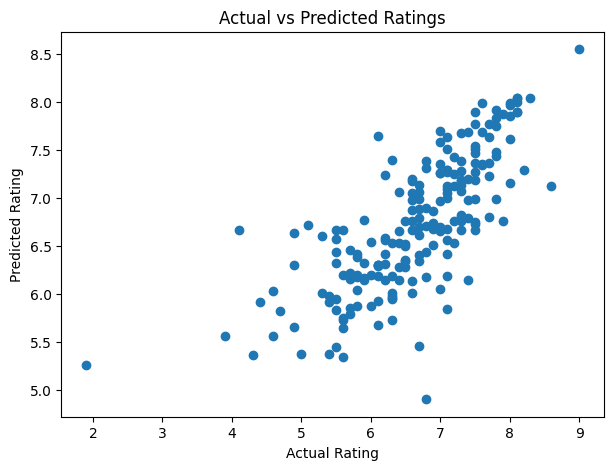

In [307]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, best_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.show()

## 22. Prediction on New Data

Finally, we use the selected model to predict the rating of a new
movie.

This demonstrates how our trained machine learning model can be used
with unseen data.

In [308]:
new_movie = pd.DataFrame({
    "Genre": ["Action,Adventure,Sci-Fi"],
    "Director": ["James Gunn"],
    "Year": [2020],
    "Runtime (Minutes)": [120],
    "Votes": [500000],
    "Revenue (Millions)": [250],
    "Metascore": [75],
    "Movie_Age": [latest_year - 2020]
})

In [309]:
prediction = best_model.predict(new_movie)

print("Predicted IMDb Rating:", round(prediction[0], 2))

Predicted IMDb Rating: 7.99


# 23. Conclusion

In this project, we developed a machine learning model to predict
IMDb movie ratings.

We first explored the dataset and checked its structure, missing values,
duplicates and outliers.

The missing values were handled using median imputation.

We created a new feature called Movie_Age and selected useful features
for prediction.

The categorical features Genre and Director were converted into
numerical values using One-Hot Encoding.

We trained three regression models:
- Linear Regression
- Random Forest Regression
- Gradient Boosting Regression

The models were evaluated using MAE, RMSE and R² score.

Based on the evaluation results, the model with the highest R² score
was selected as the best model.

Finally, the selected model was used to predict the rating of a new
unseen movie.

This completes the end-to-end machine learning workflow for IMDb
movie rating prediction.